In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.decomposition import PCA

from simplexity.generative_processes.builder import build_hidden_markov_model
from simplexity.generative_processes.generator import generate_data_batch_with_full_history
from simplexity.utils.pytorch_utils import jax_to_torch

from tqdm.auto import tqdm

# Load models via TransformerLens
import transformer_lens as tl

/home/chiragr2/miniconda3/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# print(f"Using device: {device}")
# if device == 'cuda':
#     for i in range(torch.cuda.device_count()):
#         props = torch.cuda.get_device_properties(i)
#         print(f"  GPU {i}: {props.name} — {props.total_mem / 1e9:.1f} GB")

## Create Sequence

In [3]:
SEQ_LENGTH = 4000
HMM_CONCEPTS = ['A', 'B', 'C']
N_SEQUENCES = 10

In [4]:
hmm = build_hidden_markov_model(
    "mess3",
    process_params={"x": 0.05, "a": 0.85},
    device=None,
)

print(f"Vocab size (symbols): {hmm.vocab_size}")
print(f"Num hidden states: {hmm.num_states}")
print(f"Initial state (belief): {jax_to_torch(hmm.initial_state).tolist()}")

emission_rows = []
for i in range(hmm.num_states):
    pure_state = jnp.zeros(hmm.num_states).at[i].set(1.0)
    obs_probs = hmm.observation_probability_distribution(pure_state)
    emission_rows.append(jax_to_torch(obs_probs))
emission_matrix = torch.stack(emission_rows)

print(f"\nEmission matrix (rows=states, cols=tokens A,B,C):")
print(emission_matrix)
print(f"\nRow sums (should be 1): {emission_matrix.sum(dim=1)}")

Vocab size (symbols): 3
Num hidden states: 3
Initial state (belief): [0.33333343267440796, 0.3333333134651184, 0.33333325386047363]

Emission matrix (rows=states, cols=tokens A,B,C):
tensor([[0.7725, 0.1137, 0.1137],
        [0.1137, 0.7725, 0.1137],
        [0.1138, 0.1138, 0.7725]])

Row sums (should be 1): tensor([1., 1., 1.])


In [5]:
sequence_len = SEQ_LENGTH + 1
key = jax.random.PRNGKey(42)
gen_states = jnp.tile(hmm.initial_state, (N_SEQUENCES, 1))

next_states, belief_states_jax, prefix_probs, inputs_jax, labels_jax = generate_data_batch_with_full_history(
    gen_states, hmm, N_SEQUENCES, sequence_len, key
)

tokens = jax_to_torch(inputs_jax)                # (N_SEQUENCES, SEQ_LENGTH)
tokens_y = jax_to_torch(labels_jax)              # (N_SEQUENCES, SEQ_LENGTH)
belief_states_all = jax_to_torch(belief_states_jax).cpu().numpy()  # (N_SEQUENCES, SEQ_LENGTH+1, 3)
obs_probs_all_jax = jnp.einsum('bns,vst->bnv', belief_states_jax, hmm.transition_matrices)
obs_probs_all= jax_to_torch(obs_probs_all_jax)


walk_concepts = [[HMM_CONCEPTS[int(t)] for t in seq] for seq in tokens]

print(f"Num sequences: {tokens.shape[0]}, Sequence length: {tokens.shape[1]}")
print(f"First 20 tokens (seq 0): {walk_concepts[0][:20]}")
print(f"Belief states shape: {belief_states_all.shape}")
print(f"Sample belief state at position 0 (prior): {belief_states_all[0, 0]}")
print(f"Sample belief state at position 100 (seq 0): {belief_states_all[0, 100]}")
print(f"Belief states sum to 1? {np.allclose(belief_states_all.sum(axis=-1), 1)}")
print(f"Sample observation probabilities: {obs_probs_all[0, 1]}")
total_concepts = [c for seq in walk_concepts for c in seq]
print(f"\nToken distribution (all seqs): A={total_concepts.count('A')}, B={total_concepts.count('B')}, C={total_concepts.count('C')}")

Num sequences: 10, Sequence length: 4000
First 20 tokens (seq 0): ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'B', 'B', 'B', 'A', 'C', 'C', 'A', 'C', 'C', 'C', 'A', 'B']
Belief states shape: (10, 4001, 3)
Sample belief state at position 0 (prior): [0.33333343 0.3333333  0.33333325]
Sample belief state at position 100 (seq 0): [0.05919884 0.0122143  0.9285869 ]
Belief states sum to 1? True
Sample observation probabilities: tensor([0.1632, 0.1632, 0.6737])

Token distribution (all seqs): A=13293, B=13181, C=13526


## Prepare Model

In [6]:
use_tl = True
if use_tl:
    MODEL_NAME = "meta-llama/Llama-3.2-3B"
    N_DEVICES = min(torch.cuda.device_count(), 4)

    print(f"Loading {MODEL_NAME} across {N_DEVICES} GPUs...")
    model = tl.HookedTransformer.from_pretrained(
        MODEL_NAME,
        device="cuda",
        n_devices=N_DEVICES,
        torch_dtype=torch.float16,
        n_ctx=4098
    )
    model.eval()
    print(f"Model loaded. {model.cfg.n_layers} layers, d_model={model.cfg.d_model}")
    print(f"Context window: {model.cfg.n_ctx}")

else:
    from src.models.llm_interface import LlamaInterface

    model = LlamaInterface("llama-3.1-8b")


Loading meta-llama/Llama-3.2-3B across 4 GPUs...


`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.36it/s]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer
Model loaded. 28 layers, d_model=3072
Context window: 4098


In [7]:
def get_concept_token_ids(model, concepts):
    global use_tl
    """Get the token IDs for each concept (with space prefix)."""
    concept_to_id = {}
    for concept in concepts:
        spaced = f" {concept}"
        if use_tl:
            ids = model.to_tokens(spaced, prepend_bos=False)[0]
            concept_to_id[concept] = ids[-1].item()
        else:
            ids, tokens = model.tokenize(spaced)
            concept_to_id[concept] = ids[-1]
    return concept_to_id

In [8]:
belief_states_all.shape

(10, 4001, 3)

## Run Forward Pass

In [9]:
sequence_len = SEQ_LENGTH + 1
key = jax.random.PRNGKey(42)
gen_states = jnp.tile(hmm.initial_state, (N_SEQUENCES, 1))

next_states, belief_states_jax, prefix_probs, inputs_jax, labels_jax = generate_data_batch_with_full_history(
    gen_states, hmm, N_SEQUENCES, sequence_len, key
)

tokens = jax_to_torch(inputs_jax)                # (N_SEQUENCES, SEQ_LENGTH)
tokens_y = jax_to_torch(labels_jax)              # (N_SEQUENCES, SEQ_LENGTH)
belief_states_all = jax_to_torch(belief_states_jax).cpu().numpy()  # (N_SEQUENCES, SEQ_LENGTH+1, 3)
obs_probs_all_jax = jnp.einsum('bns,vst->bnv', belief_states_jax, hmm.transition_matrices)
obs_probs_all = jax_to_torch(obs_probs_all_jax)

walk_concepts = [[HMM_CONCEPTS[int(t)] for t in seq] for seq in tokens]

print(f"Num sequences: {tokens.shape[0]}, Sequence length: {tokens.shape[1]}")
print(f"First 20 tokens (seq 0): {walk_concepts[0][:20]}")
print(f"Belief states shape: {belief_states_all.shape}")
print(f"Sample belief state at position 0 (prior): {belief_states_all[0, 0]}")
print(f"Sample belief state at position 100 (seq 0): {belief_states_all[0, 100]}")
print(f"Belief states sum to 1? {np.allclose(belief_states_all.sum(axis=-1), 1)}")
print(f"Sample observation probabilities: {obs_probs_all[0, 1]}")
total_concepts = [c for seq in walk_concepts for c in seq]
print(f"\nToken distribution (all seqs): A={total_concepts.count('A')}, B={total_concepts.count('B')}, C={total_concepts.count('C')}")

Num sequences: 10, Sequence length: 4000
First 20 tokens (seq 0): ['C', 'C', 'C', 'C', 'C', 'C', 'C', 'C', 'B', 'B', 'B', 'A', 'C', 'C', 'A', 'C', 'C', 'C', 'A', 'B']
Belief states shape: (10, 4001, 3)
Sample belief state at position 0 (prior): [0.33333343 0.3333333  0.33333325]
Sample belief state at position 100 (seq 0): [0.05919884 0.0122143  0.9285869 ]
Belief states sum to 1? True
Sample observation probabilities: tensor([0.1632, 0.1632, 0.6737])

Token distribution (all seqs): A=13293, B=13181, C=13526


In [10]:
if use_tl:
    LAYERS_TO_ANALYZE = list(range(0, model.cfg.n_layers, 4)) + [model.cfg.n_layers - 1]
    LAYERS_TO_ANALYZE = sorted(set(LAYERS_TO_ANALYZE))
    print(f"Will analyze layers: {LAYERS_TO_ANALYZE}")

    letter_set = set(HMM_CONCEPTS)

    all_activations = {layer: [] for layer in LAYERS_TO_ANALYZE}
    all_logits = []
    all_beliefs = []
    all_positions = []

    for seq_idx in tqdm(range(N_SEQUENCES), desc="Processing sequences"):
        seq_concepts = walk_concepts[seq_idx]
        beliefs = belief_states_all[seq_idx]  # (SEQ_LENGTH+1, 3)

        # Create prompt from seq
        prompt = seq_concepts[0] + " " + " ".join(seq_concepts[1:])
        input_ids = model.to_tokens(prompt, prepend_bos=True).to(model.embed.W_E.device)  # (1, n_tokens)
        str_tokens = model.to_str_tokens(prompt, prepend_bos=True)

        # Remove truncate if sequence exceeds context window from Andrews code for now

        # Find positions of letter tokens (A, B, C) in the tokenized sequence
        positions = [i for i, tok in enumerate(str_tokens) if tok.strip() in letter_set]

        n_use = min(len(positions), len(seq_concepts))
        if len(positions) != len(seq_concepts):
            print(f"Warning seq {seq_idx}: expected {len(seq_concepts)} letter positions, got {len(positions)}")
        positions = positions[:n_use]

        with torch.no_grad():
            _, cache = model.run_with_cache(
                input_ids,
                names_filter=[f"blocks.{l}.hook_resid_post" for l in LAYERS_TO_ANALYZE],
                return_type=None,
            )

        for layer in LAYERS_TO_ANALYZE:
            hook_name = f"blocks.{layer}.hook_resid_post"
            layer_acts = cache[hook_name][0]  # (seq_len, d_model)
            letter_acts = layer_acts[positions].cpu().float().numpy()
            all_activations[layer].append(letter_acts)

        last_resid = cache[f"blocks.{LAYERS_TO_ANALYZE[-1]}.hook_resid_post"]
        last_resid = last_resid.to(model.unembed.W_U.device)
        logits = model.unembed(model.ln_final(last_resid))  # (1, seq_len, vocab_size)
        seq_logits = logits[0, positions].cpu().float().detach().numpy()  # (n_use, vocab_size)
        all_logits.append(seq_logits)
        del logits, last_resid

        # beliefs[1:n_use+1] = belief AFTER seeing each of the first n_use tokens
        all_beliefs.append(beliefs[1:n_use + 1])
        all_positions.append(np.arange(n_use))

        del cache
        torch.cuda.empty_cache()

    for layer in LAYERS_TO_ANALYZE:
        all_activations[layer] = np.concatenate(all_activations[layer], axis=0)
    all_logits_flat = np.concatenate(all_logits, axis=0)
    all_beliefs_flat = np.concatenate(all_beliefs, axis=0)
    all_positions_flat = np.concatenate(all_positions, axis=0)

    print(f"\nTotal datapoints: {len(all_beliefs_flat)}")
    print(f"Logits shape: {all_logits_flat.shape}")
    print(f"Activations shape per layer: {all_activations[LAYERS_TO_ANALYZE[0]].shape}")
    print(f"Beliefs shape: {all_beliefs_flat.shape}")
    print(f"Position range: {all_positions_flat.min()} to {all_positions_flat.max()}")

else:
    print("Running single forward pass...")

    concept_to_id = get_concept_token_ids(model, HMM_CONCEPTS)
    concept_ids = torch.tensor([concept_to_id[c] for c in HMM_CONCEPTS])
    print(f"Concept token IDs: {concept_to_id}")

    seq0 = walk_concepts[0]
    text = seq0[0] + " " + " ".join(seq0[1:])
    inputs = model.tokenizer(text, return_tensors="pt").to(model.device)
    input_ids = inputs.input_ids[0]
    print(f"Input sequence length (tokens): {len(input_ids)}")

    with torch.no_grad():
        outputs = model.model(**inputs, output_hidden_states=True, return_dict=True)
        logits = outputs.logits[0]
    print(f"Logits shape: {logits.shape}")

    concept_ids_device = concept_ids.to(logits.device)
    concept_logits = logits[:, concept_ids_device]
    llm_probs = F.softmax(concept_logits, dim=1)
    print(f"LLM probs shape: {llm_probs.shape}")

Will analyze layers: [0, 4, 8, 12, 16, 20, 24, 27]


Processing sequences:   0%|          | 0/10 [00:00<?, ?it/s]

Processing sequences:   0%|          | 0/10 [00:00<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 1.43 GiB. GPU 2 has a total capacity of 7.92 GiB of which 1.19 GiB is free. Including non-PyTorch memory, this process has 6.73 GiB memory in use. Of the allocated memory 6.58 GiB is allocated by PyTorch, and 23.07 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
len(all_logits)

10

In [ ]:
concept_to_id = get_concept_token_ids(model, HMM_CONCEPTS)
concept_ids = [concept_to_id[c] for c in HMM_CONCEPTS]
print(f"Concept token IDs (ordered): {dict(zip(HMM_CONCEPTS, concept_ids))}")

concept_logits = all_logits_flat[:, concept_ids]  # (total_datapoints, n_concepts)
llm_probs = F.softmax(torch.tensor(concept_logits), dim=-1).numpy()

print(f"Concept logits shape: {concept_logits.shape}")
print(f"LLM probs shape: {llm_probs.shape}")
print(f"Sample probs (first 3): {llm_probs[:3]}")

Concept token IDs (ordered): {'A': 362, 'B': 426, 'C': 356}
Concept logits shape: (20000, 3)
LLM probs shape: (20000, 3)
Sample probs (first 3): [[0.57166034 0.08430848 0.34403124]
 [0.07663476 0.03944819 0.88391703]
 [0.02891191 0.01365702 0.9574311 ]]


LLM probs reshaped: (10, 2000, 3)
HMM obs probs:      (10, 2000, 3)


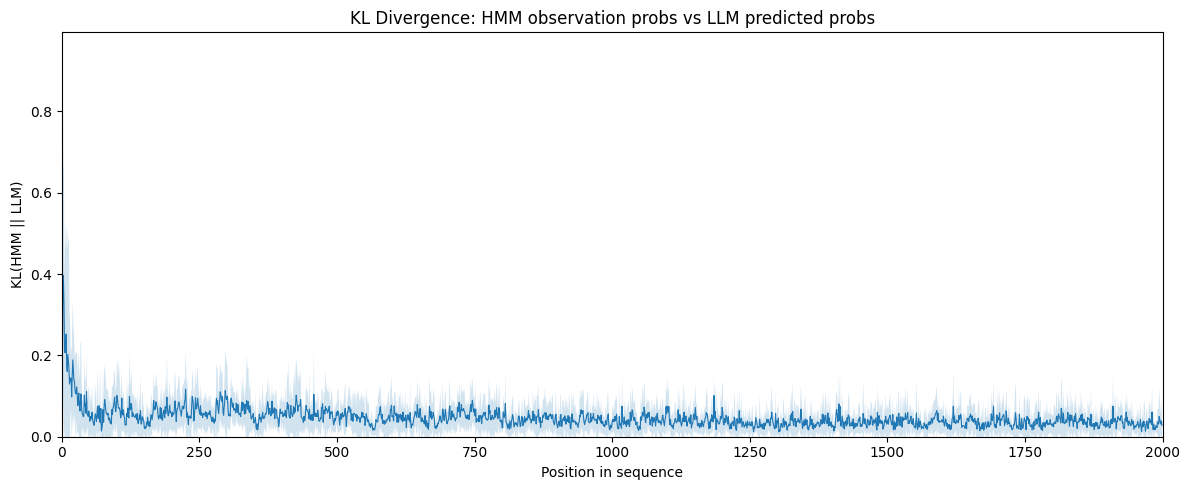

Mean KL over all positions: 0.0465
KL at position 1: 0.5869, KL at position 10: 0.1604, at position 100: 0.1017, at position 1000: 0.0356


In [ ]:
# Reshape LLM probs back to (N_SEQUENCES, SEQ_LENGTH, n_concepts)
llm_probs_3d = llm_probs.reshape(N_SEQUENCES, SEQ_LENGTH, len(HMM_CONCEPTS))
hmm_probs = obs_probs_all[:, 1:, :].cpu().numpy()  # (N_SEQUENCES, SEQ_LENGTH, 3)

print(f"LLM probs reshaped: {llm_probs_3d.shape}")
print(f"HMM obs probs:      {hmm_probs.shape}")

eps = 1e-10
p = np.clip(hmm_probs, eps, 1.0)
q = np.clip(llm_probs_3d, eps, 1.0)

# KL(HMM || LLM) per position: sum over concepts, average over sequences
kl_per_pos_seq = np.sum(p * np.log(p / q), axis=-1)  # (N_SEQUENCES, SEQ_LENGTH)
kl_mean = kl_per_pos_seq.mean(axis=0)  # (SEQ_LENGTH,)
kl_std = kl_per_pos_seq.std(axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
positions_arr = np.arange(SEQ_LENGTH)
ax.plot(positions_arr, kl_mean, linewidth=0.8)
ax.fill_between(positions_arr, kl_mean - kl_std, kl_mean + kl_std, alpha=0.2)
ax.set_xlabel('Position in sequence')
ax.set_ylabel('KL(HMM || LLM)')
ax.set_title('KL Divergence: HMM observation probs vs LLM predicted probs')
ax.set_xlim(0, SEQ_LENGTH)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

print(f"Mean KL over all positions: {kl_mean.mean():.4f}")
print(f"KL at position 1: {kl_mean[0]:.4f}, KL at position 10: {kl_mean[10]:.4f}, at position 100: {kl_mean[100]:.4f}, at position 1000: {kl_mean[1000]:.4f}")

## Extract Activations

In [ ]:
if not use_tl:
    hidden_states_llm = outputs.hidden_states
    print(f"Number of hidden state layers: {len(hidden_states_llm)}")
    print(f"Each layer shape: {hidden_states_llm[0].shape}")

    layer_indices = {'layer_26': 26, 'last_layer': -1}
    activations_by_layer = {}

    for name, layer_idx in layer_indices.items():
        activations = hidden_states_llm[layer_idx].squeeze(0)
        activations_by_layer[name] = activations.cpu().float().numpy()
        print(f"{name} activations shape: {activations_by_layer[name].shape}")

## Linear Probe

In [ ]:
belief_states_all.shape

(10, 2001, 3)

In [ ]:
# Fit linear regression for each layer (on ALL context positions)

regression_results = {}

for layer in LAYERS_TO_ANALYZE:
    acts = all_activations[layer]
    beliefs = all_beliefs_flat
    
    # Train/test split for cross-validation
    X_train, X_test, y_train, y_test = train_test_split(
        acts, beliefs, test_size=0.2, random_state=42
    )
    
    reg = LinearRegression()
    reg.fit(X_train, y_train)
    
    # Evaluate
    y_pred_train = reg.predict(X_train)
    y_pred_test = reg.predict(X_test)
    
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)
    
    # Project all activations
    projected = reg.predict(acts)
    
    regression_results[layer] = {
        'model': reg,
        'mse_train': mse_train,
        'mse_test': mse_test,
        'projected': projected,
    }
    
    print(f"Layer {layer:2d}: MSE train={mse_train:.6f}, MSE test={mse_test:.6f}")

Layer  0: MSE train=0.000986, MSE test=0.000989
Layer  4: MSE train=0.000098, MSE test=0.000129
Layer  8: MSE train=0.000272, MSE test=0.000492
Layer 12: MSE train=0.000615, MSE test=0.001056
Layer 16: MSE train=0.000625, MSE test=0.000987
Layer 20: MSE train=0.000682, MSE test=0.001019
Layer 24: MSE train=0.000677, MSE test=0.001057
Layer 27: MSE train=0.000737, MSE test=0.001287


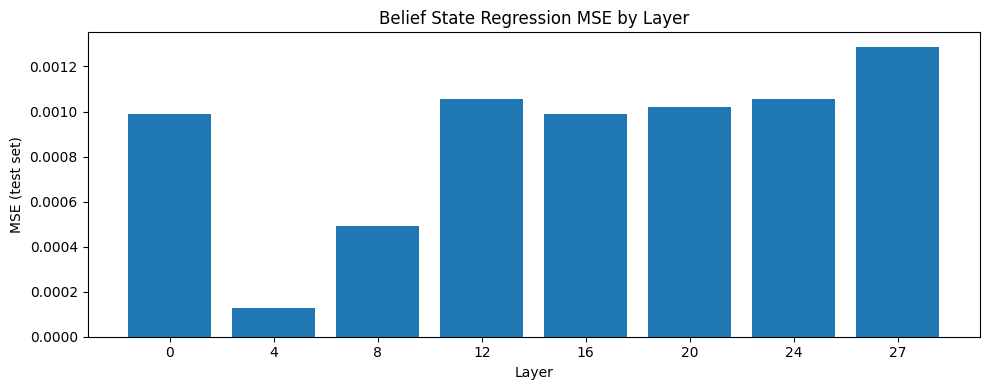

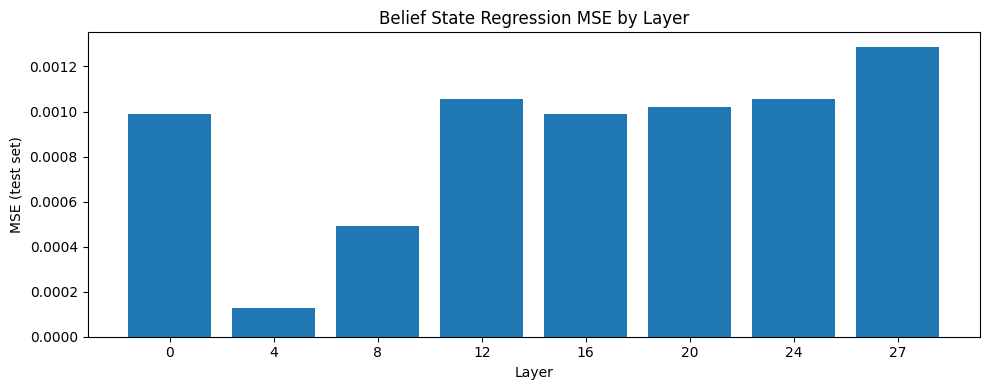

In [ ]:
# Plot MSE across layers

fig, ax = plt.subplots(1, 1, figsize=(10, 4))

layers = sorted(regression_results.keys())
mse_train = [regression_results[l]['mse_test'] for l in layers]

ax.bar(range(len(layers)), mse_train, tick_label=[str(l) for l in layers])
ax.set_xlabel('Layer')
ax.set_ylabel('MSE (test set)')
ax.set_title('Belief State Regression MSE by Layer')
plt.tight_layout()
plt.savefig('mse.pdf')
plt.show()# Plot MSE across layers

fig, ax = plt.subplots(1, 1, figsize=(10, 4))

layers = sorted(regression_results.keys())
mse_train = [regression_results[l]['mse_test'] for l in layers]

ax.bar(range(len(layers)), mse_train, tick_label=[str(l) for l in layers])
ax.set_xlabel('Layer')
ax.set_ylabel('MSE (test set)')
ax.set_title('Belief State Regression MSE by Layer')
plt.tight_layout()
plt.show()

In [ ]:
from src.hmm.hmm import belief_to_barycentric

In [ ]:
# Simplex visualizations for select layers

show_layers = LAYERS_TO_ANALYZE
show_layers = sorted(set(show_layers))

# Ground truth belief states on the simplex
print("Ground Truth Belief States")
belief_to_barycentric(all_beliefs_flat.reshape(-1, 3), all_beliefs_flat.reshape(-1, 3))

# Per-layer projections on the simplex
for layer in show_layers:
    projected = regression_results[layer]['projected']

    proj_clipped = np.clip(projected, 0, 1)
    row_sums = proj_clipped.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    proj_clipped = proj_clipped / row_sums

    mse = regression_results[layer]['mse_test']
    print(f"Layer {layer} — MSE={mse:.4f}")
    belief_to_barycentric(proj_clipped.reshape(-1, 3), all_beliefs_flat.reshape(-1, 3))

Ground Truth Belief States


Layer 0 — MSE=0.0010


Layer 4 — MSE=0.0001


Layer 8 — MSE=0.0005


Layer 12 — MSE=0.0011


Layer 16 — MSE=0.0010


Layer 20 — MSE=0.0010


Layer 24 — MSE=0.0011


Layer 27 — MSE=0.0013


## Visualize Projected Belief States by Layer

In [ ]:
from src.hmm.hmm import belief_to_barycentric

In [ ]:
all_beliefs_flat.shape

(500, 3)

In [ ]:
belief_to_barycentric(all_beliefs_flat.reshape(-1,3), all_beliefs_flat.reshape(-1,3))

NameError: name 'beliefs_to_cartesian' is not defined

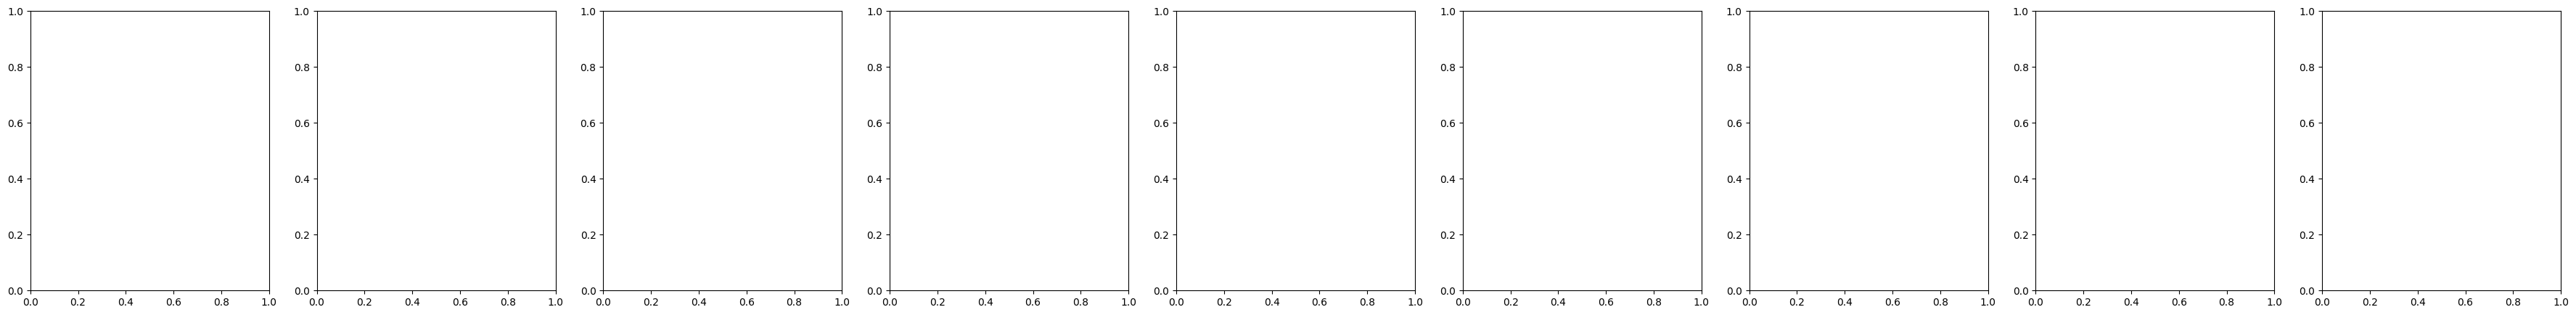

In [ ]:
# Simplex visualizations for select layers

# Determine which layers to plot
show_layers = LAYERS_TO_ANALYZE
show_layers = sorted(set(show_layers))

n_show = len(show_layers) + 1  # +1 for ground truth
fig, axes = plt.subplots(1, n_show, figsize=(5*n_show, 5))

# Ground truth
ax = axes[0]
gt_x, gt_y = beliefs_to_cartesian(all_beliefs_flat)
gt_colors = beliefs_to_colors(all_beliefs_flat)
ax.scatter(gt_x, gt_y, c=gt_colors, s=1, alpha=0.3, rasterized=True)
ax.set_title('Ground Truth\nBelief States', fontsize=12)
ax.set_aspect('equal')
ax.axis('off')

# Per-layer projections
for idx, layer in enumerate(show_layers):
    ax = axes[idx + 1]
    projected = regression_results[layer]['projected']
    
    # Clip to valid probability simplex
    proj_clipped = np.clip(projected, 0, 1)
    row_sums = proj_clipped.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    proj_clipped = proj_clipped / row_sums
    
    px, py = beliefs_to_cartesian(proj_clipped)
    p_colors = beliefs_to_colors(all_beliefs_flat)  # color by ground truth
    
    ax.scatter(px, py, c=p_colors, s=1, alpha=0.3, rasterized=True)
    mse = regression_results[layer]['mse_test']
    ax.set_title(f'Layer {layer}\nMSE={mse:.4f}', fontsize=12)
    ax.set_aspect('equal')
    ax.axis('off')

fig.suptitle('Belief State Geometry: Ground Truth vs. Linear Projections from Residual Stream', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('mess3.pdf')
plt.show()

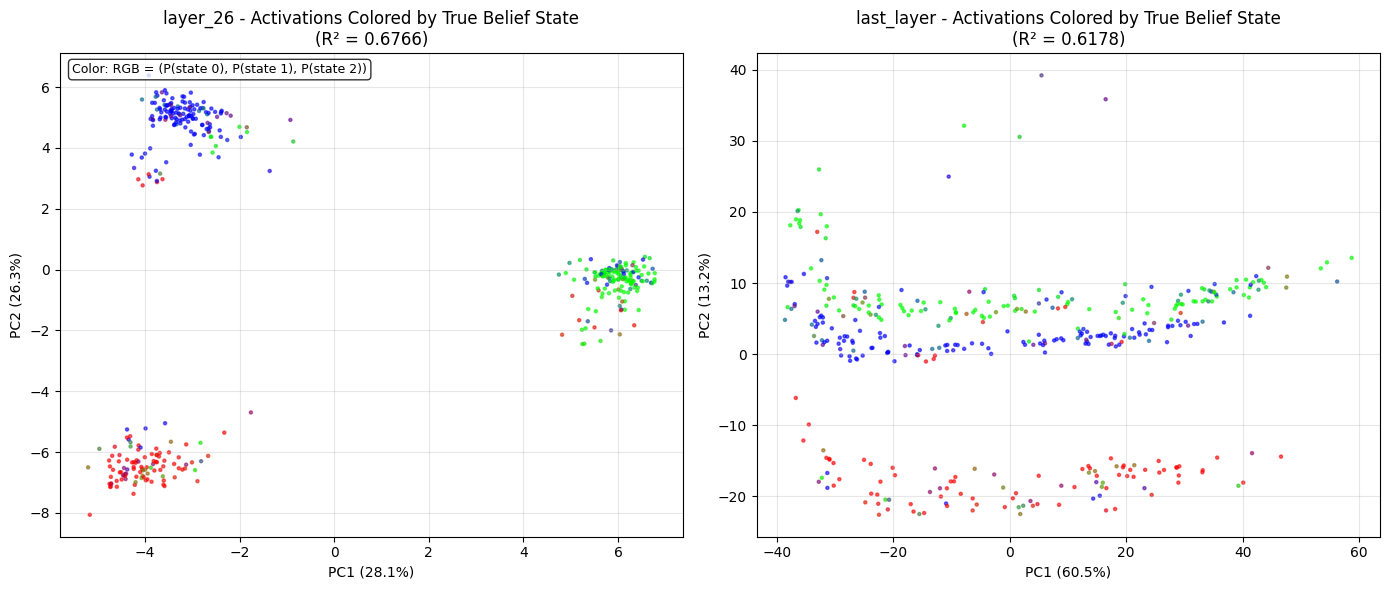

Figure saved to: linear_probe_belief_states.png


In [ ]:
# --- Visualize Activations Colored by Belief States ---

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, (layer_name, result) in enumerate(results.items()):
    ax = axes[idx]
    
    # Get activations and belief states for test set
    X_test = result['X_test']
    y_test = result['y_test']
    y_pred = result['y_pred_test']
    
    # Reduce to 2D with PCA
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X_test)
    
    # Use belief states as RGB colors (3 states = RGB)
    # Clip to [0, 1] range for valid colors
    colors = np.clip(y_test, 0, 1)
    
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, s=5, alpha=0.6)
    ax.set_title(f'{layer_name} - Activations Colored by True Belief State\n(R² = {result["r2_test"]:.4f})')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.grid(True, alpha=0.3)

# Add explanation for colors
axes[0].text(0.02, 0.98, 'Color: RGB = (P(state 0), P(state 1), P(state 2))', 
             transform=axes[0].transAxes, fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
plt.tight_layout()
plt.savefig('linear_probe_belief_states.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Figure saved to: linear_probe_belief_states.png")